In [8]:
# Using AdaBoost – CASE 1 - Diabetes - Yes/No (Classification) & CASE 3 - Risk Score (Regression)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings(
    "ignore",
    message=".*SAMME.R algorithm.*",
    category=FutureWarning
)

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    KFold,
    GridSearchCV,
    cross_validate
)
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score
)
from sklearn.ensemble import AdaBoostClassifier, AdaBoostRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

In [9]:
# 0. LOAD RAW DATA
df = pd.read_csv("diabetes_dataset.csv")

#NON-INVASIVE FEATURE ENCODING

# Lab / invasive variables
lab_cols = [
    "cholesterol_total",
    "hdl_cholesterol", "ldl_cholesterol",
    "triglycerides", "glucose_fasting", "glucose_postprandial",
    "insulin_level",
    "hba1c",
    "diabetes_risk_score",   # dropped here for classification features
    "diabetes_stage"
]

# ---------- CASE 1 base table (non-invasive + diagnosed_diabetes) ----------
Z_cls = df.drop(columns=lab_cols, errors="ignore").copy()

# Separate categorical and numeric columns
cat_cols_cls = Z_cls.select_dtypes(include=["object", "category"]).columns
num_cols_cls = Z_cls.select_dtypes(include=["number"]).columns

# One-hot encode categorical vars
encoded_cls = pd.get_dummies(Z_cls[cat_cols_cls], drop_first=True)

# Final encoded dataset for classification
df_cls = pd.concat([Z_cls[num_cols_cls], encoded_cls], axis=1)
df_cls = df_cls.dropna().reset_index(drop=True)

print("Classification (Case 1) encoded shape:", df_cls.shape)
print("Classification columns:", df_cls.columns.tolist())

Classification (Case 1) encoded shape: (100000, 33)
Classification columns: ['age', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week', 'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'family_history_diabetes', 'hypertension_history', 'cardiovascular_history', 'bmi', 'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'diagnosed_diabetes', 'gender_Male', 'gender_Other', 'ethnicity_Black', 'ethnicity_Hispanic', 'ethnicity_Other', 'ethnicity_White', 'education_level_Highschool', 'education_level_No formal', 'education_level_Postgraduate', 'income_level_Low', 'income_level_Lower-Middle', 'income_level_Middle', 'income_level_Upper-Middle', 'employment_status_Retired', 'employment_status_Student', 'employment_status_Unemployed', 'smoking_status_Former', 'smoking_status_Never']



Case 1 class balance in full data:
diagnosed_diabetes
1    59998
0    40002
Name: count, dtype: int64

================ CASE 1 – GridSearch (AdaBoostClassifier) ================
Fitting 5 folds for each of 18 candidates, totalling 90 fits


/apps/python/3.10/lib/python3.10/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/apps/python/3.10/lib/python3.10/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/apps/python/3.10/lib/python3.10/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/apps/python/3.10/lib/python3.10/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.wa


Best parameters:
{'estimator__max_depth': 1, 'learning_rate': 0.05, 'n_estimators': 50}
Best CV F1 score: 0.7514

=== CASE 1 – Test Set Evaluation (AdaBoostClassifier) ===
Accuracy:  0.6059
Precision: 0.6056
Recall:    0.9846
F1 Score:  0.7499
ROC-AUC:   0.6492

Confusion matrix (Case 1):
 [[  304  7696]
 [  185 11815]]

Classification report (Case 1):

              precision    recall  f1-score   support

           0     0.6217    0.0380    0.0716      8000
           1     0.6056    0.9846    0.7499     12000

    accuracy                         0.6059     20000
   macro avg     0.6136    0.5113    0.4108     20000
weighted avg     0.6120    0.6059    0.4786     20000



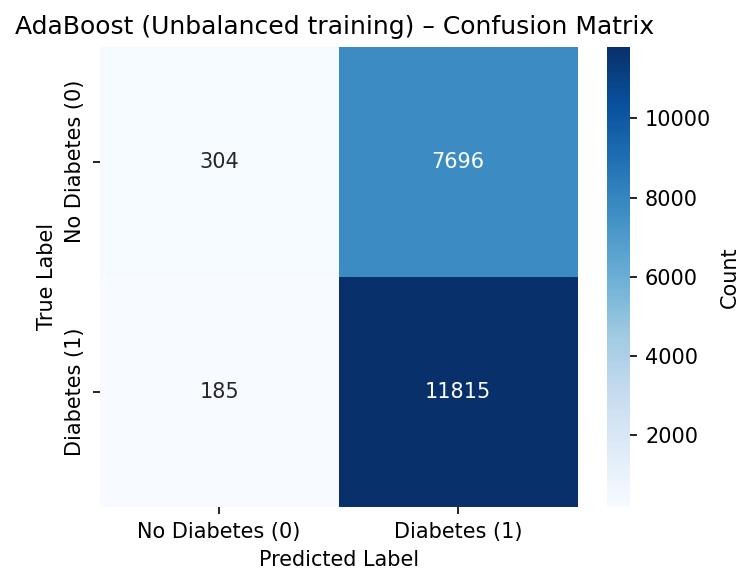

/apps/python/3.10/lib/python3.10/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/apps/python/3.10/lib/python3.10/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/apps/python/3.10/lib/python3.10/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/apps/python/3.10/lib/python3.10/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.wa


=== CASE 1 – Cross-validation of Best AdaBoost Model ===
accuracy : 0.6079 ± 0.0013
precision: 0.6064 ± 0.0011
recall   : 0.9872 ± 0.0028
f1       : 0.7513 ± 0.0004
roc_auc  : 0.6496 ± 0.0030
[CV] END estimator__max_depth=1, learning_rate=0.05, n_estimators=50; total time=   5.2s
[CV] END estimator__max_depth=1, learning_rate=0.05, n_estimators=100; total time=   8.3s
[CV] END estimator__max_depth=1, learning_rate=0.05, n_estimators=200; total time=  18.8s
[CV] END estimator__max_depth=1, learning_rate=0.1, n_estimators=50; total time=   4.5s
[CV] END estimator__max_depth=1, learning_rate=0.1, n_estimators=100; total time=   9.2s
[CV] END estimator__max_depth=1, learning_rate=0.1, n_estimators=200; total time=  19.2s
[CV] END estimator__max_depth=1, learning_rate=0.5, n_estimators=50; total time=   4.2s
[CV] END estimator__max_depth=1, learning_rate=0.5, n_estimators=100; total time=   7.9s
[CV] END estimator__max_depth=1, learning_rate=0.5, n_estimators=200; total time=  18.9s
[CV] E

In [13]:
# CASE 1 – ADABOOST CLASSIFIER ON DIAGNOSED_DIABETES

# Target and features
y1 = df_cls["diagnosed_diabetes"]
X1 = df_cls.drop(columns=["diagnosed_diabetes"]).copy()

# Train–test split
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42, stratify=y1
)

print("\nCase 1 class balance in full data:")
print(y1.value_counts())

# Base estimator (weak learner)
base_estimator_clf = DecisionTreeClassifier(random_state=42)

# AdaBoost classifier
ada_clf = AdaBoostClassifier(
    estimator=base_estimator_clf,
    random_state=42
)

# Hyperparameter grid
param_grid_clf = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.05, 0.1, 0.5],
    "estimator__max_depth": [1, 2],
}

# Stratified 5-fold CV
cv1 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# GridSearch – use F1 score
grid_ada_clf = GridSearchCV(
    estimator=ada_clf,
    param_grid=param_grid_clf,
    scoring="f1",           # F1 for positive class (diabetes)
    cv=cv1,
    n_jobs=-1,
    verbose=2
)

print("\n================ CASE 1 – GridSearch (AdaBoostClassifier) ================")
grid_ada_clf.fit(X1_train, y1_train)

print("\nBest parameters:")
print(grid_ada_clf.best_params_)
print(f"Best CV F1 score: {grid_ada_clf.best_score_:.4f}")

best_ada_clf = grid_ada_clf.best_estimator_

# -------- Test-set evaluation--------
y1_pred = best_ada_clf.predict(X1_test)
y1_proba = best_ada_clf.predict_proba(X1_test)[:, 1]

acc1  = accuracy_score(y1_test, y1_pred)
prec1 = precision_score(y1_test, y1_pred)
rec1  = recall_score(y1_test, y1_pred)
f1_1  = f1_score(y1_test, y1_pred)
roc1  = roc_auc_score(y1_test, y1_proba)

print("\n=== CASE 1 – Test Set Evaluation (AdaBoostClassifier) ===")
print(f"Accuracy:  {acc1:.4f}")
print(f"Precision: {prec1:.4f}")
print(f"Recall:    {rec1:.4f}")
print(f"F1 Score:  {f1_1:.4f}")
print(f"ROC-AUC:   {roc1:.4f}")

# Confusion matrix
cm1 = confusion_matrix(y1_test, y1_pred)
print("\nConfusion matrix (Case 1):\n", cm1)
print("\nClassification report (Case 1):\n")
print(classification_report(y1_test, y1_pred, digits=4))

# Heatmap for the slide
plt.figure(figsize=(5, 4),dpi=150)
sns.heatmap(
    cm1,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Diabetes (0)", "Diabetes (1)"],
    yticklabels=["No Diabetes (0)", "Diabetes (1)"],
    cbar_kws={"label": "Count"}
)
plt.title("AdaBoost (Unbalanced training) – Confusion Matrix ")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.savefig("case1_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

#Cross-validation of the BEST model (stability)
scoring_dict = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_results_best = cross_validate(
    best_ada_clf,
    X1,
    y1,
    cv=cv1,
    scoring=scoring_dict,
    n_jobs=-1
)

print("\n=== CASE 1 – Cross-validation of Best AdaBoost Model ===")
for metric, values in cv_results_best.items():
    if metric.startswith("test_"):
        name = metric.replace("test_", "")
        print(f"{name:9s}: {values.mean():.4f} ± {values.std():.4f}")

In [12]:
# === TABLE: F1 score for each fold (Case 1 – Unbalanced) ===

# Run StratifiedKFold manually to extract per-fold F1 scores
from sklearn.model_selection import StratifiedKFold

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X1, y1), start=1):
    X_train_f, X_val_f = X1.iloc[train_idx], X1.iloc[val_idx]
    y_train_f, y_val_f = y1.iloc[train_idx], y1.iloc[val_idx]

    # Train the BEST AdaBoost model on this fold
    best_ada_clf.fit(X_train_f, y_train_f)

    preds = best_ada_clf.predict(X_val_f)
    f1_f = f1_score(y_val_f, preds)

    fold_scores.append([fold, round(f1_f, 4)])

# Convert to a pandas table
cv_table = pd.DataFrame(fold_scores, columns=["Fold", "F1 Score"])
print("\n=== F1 Score by Fold (Case 1 – Unbalanced) ===")
print(cv_table.to_string(index=False))


=== F1 Score by Fold (Case 1 – Unbalanced) ===
 Fold  F1 Score
    1    0.7506
    2    0.7515
    3    0.7513
    4    0.7517
    5    0.7514



Class balance in ORIGINAL training set:
diagnosed_diabetes
1    47998
0    32002
Name: count, dtype: int64

Class balance in BALANCED training set:
diagnosed_diabetes
0    47998
1    47998
Name: count, dtype: int64

============ CASE 1 – GridSearch on BALANCED training data ============
Fitting 5 folds for each of 18 candidates, totalling 90 fits


/apps/python/3.10/lib/python3.10/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/apps/python/3.10/lib/python3.10/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/apps/python/3.10/lib/python3.10/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/apps/python/3.10/lib/python3.10/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.wa


Best parameters (balanced training):
{'estimator__max_depth': 2, 'learning_rate': 0.5, 'n_estimators': 200}
Best CV F1 score (balanced): 0.5969

=== CASE 1 – Test Set Evaluation (AdaBoost, BALANCED training) ===
Accuracy:  0.6012
Precision: 0.7059
Recall:    0.5748
F1 Score:  0.6337
ROC-AUC:   0.6507

Confusion matrix (BALANCED training):
 [[5126 2874]
 [5102 6898]]

Classification report (Case 1, BALANCED training):

              precision    recall  f1-score   support

           0     0.5012    0.6408    0.5624      8000
           1     0.7059    0.5748    0.6337     12000

    accuracy                         0.6012     20000
   macro avg     0.6035    0.6078    0.5980     20000
weighted avg     0.6240    0.6012    0.6052     20000



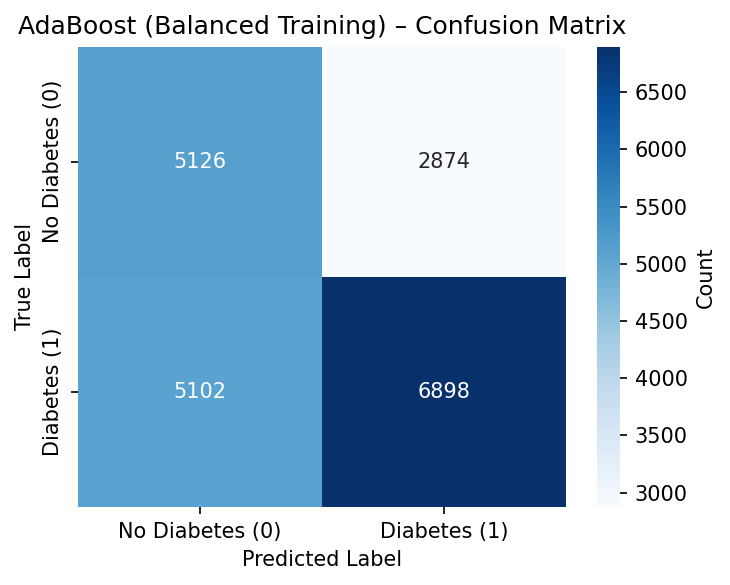

[CV] END estimator__max_depth=1, learning_rate=0.05, n_estimators=50; total time=   4.9s
[CV] END estimator__max_depth=1, learning_rate=0.05, n_estimators=100; total time=  10.5s
[CV] END estimator__max_depth=1, learning_rate=0.05, n_estimators=200; total time=  21.5s
[CV] END estimator__max_depth=1, learning_rate=0.1, n_estimators=50; total time=   4.9s
[CV] END estimator__max_depth=1, learning_rate=0.1, n_estimators=100; total time=   9.6s
[CV] END estimator__max_depth=1, learning_rate=0.1, n_estimators=200; total time=  17.6s
[CV] END estimator__max_depth=1, learning_rate=0.5, n_estimators=50; total time=   4.6s
[CV] END estimator__max_depth=1, learning_rate=0.5, n_estimators=50; total time=   6.0s
[CV] END estimator__max_depth=1, learning_rate=0.5, n_estimators=100; total time=  10.4s
[CV] END estimator__max_depth=1, learning_rate=0.5, n_estimators=200; total time=  21.7s
[CV] END estimator__max_depth=2, learning_rate=0.05, n_estimators=100; total time=  20.5s
[CV] END estimator__m

In [11]:
from sklearn.utils import resample

# ============================================================
# CASE 1 – AdaBoost with BALANCED TRAINING DATA (oversampling)
# ============================================================

# Combine X_train and y_train into a single DataFrame
train_df = X1_train.copy()
train_df["diagnosed_diabetes"] = y1_train.values

print("\nClass balance in ORIGINAL training set:")
print(train_df["diagnosed_diabetes"].value_counts())

# Identify majority and minority class
class_counts = train_df["diagnosed_diabetes"].value_counts()
majority_class = class_counts.idxmax()
minority_class = class_counts.idxmin()

df_majority = train_df[train_df["diagnosed_diabetes"] == majority_class]
df_minority = train_df[train_df["diagnosed_diabetes"] == minority_class]

# Oversample minority class to match majority
df_minority_upsampled = resample(
    df_minority,
    replace=True,                     # sample with replacement
    n_samples=len(df_majority),       # match number of majority samples
    random_state=42
)

# Create balanced training set
train_balanced = pd.concat([df_majority, df_minority_upsampled]).sample(
    frac=1.0, random_state=42        # shuffle
)

X1_train_bal = train_balanced.drop(columns=["diagnosed_diabetes"])
y1_train_bal = train_balanced["diagnosed_diabetes"]

print("\nClass balance in BALANCED training set:")
print(y1_train_bal.value_counts())

# -----------------------------
# Re-run GridSearch on BALANCED
# -----------------------------
ada_clf_bal = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    random_state=42
)

grid_ada_clf_bal = GridSearchCV(
    estimator=ada_clf_bal,
    param_grid=param_grid_clf,   # reuse same grid as before
    scoring="f1",                # still optimize F1 for diabetes class
    cv=cv1,
    n_jobs=-1,
    verbose=2
)

print("\n============ CASE 1 – GridSearch on BALANCED training data ============")
grid_ada_clf_bal.fit(X1_train_bal, y1_train_bal)

print("\nBest parameters (balanced training):")
print(grid_ada_clf_bal.best_params_)
print(f"Best CV F1 score (balanced): {grid_ada_clf_bal.best_score_:.4f}")

best_ada_clf_bal = grid_ada_clf_bal.best_estimator_

# -------- Test-set evaluation on ORIGINAL (imbalanced) test set --------
y1_pred_bal = best_ada_clf_bal.predict(X1_test)
y1_proba_bal = best_ada_clf_bal.predict_proba(X1_test)[:, 1]

acc1_bal  = accuracy_score(y1_test, y1_pred_bal)
prec1_bal = precision_score(y1_test, y1_pred_bal)
rec1_bal  = recall_score(y1_test, y1_pred_bal)
f1_1_bal  = f1_score(y1_test, y1_pred_bal)
roc1_bal  = roc_auc_score(y1_test, y1_proba_bal)

print("\n=== CASE 1 – Test Set Evaluation (AdaBoost, BALANCED training) ===")
print(f"Accuracy:  {acc1_bal:.4f}")
print(f"Precision: {prec1_bal:.4f}")
print(f"Recall:    {rec1_bal:.4f}")
print(f"F1 Score:  {f1_1_bal:.4f}")
print(f"ROC-AUC:   {roc1_bal:.4f}")

cm1_bal = confusion_matrix(y1_test, y1_pred_bal)
print("\nConfusion matrix (BALANCED training):\n", cm1_bal)
print("\nClassification report (Case 1, BALANCED training):\n")
print(classification_report(y1_test, y1_pred_bal, digits=4))

# Optional: plot confusion matrix for balanced model
plt.figure(figsize=(5, 4), dpi=150)
sns.heatmap(
    cm1_bal,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Diabetes (0)", "Diabetes (1)"],
    yticklabels=["No Diabetes (0)", "Diabetes (1)"],
    cbar_kws={"label": "Count"}
)
plt.title("AdaBoost (Balanced Training) – Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("case1_confusion_matrix_balanced.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# CASE 3 – ADABOOST REGRESSOR ON DIABETES_RISK_SCORE

# 1. Load full dataset
df = pd.read_csv("diabetes_dataset.csv")

# 2. Drop lab variables (keep diabetes_risk_score as target)
lab_cols_for_risk = [
    "cholesterol_total",
    "hdl_cholesterol", "ldl_cholesterol",
    "triglycerides",
    "glucose_fasting", "glucose_postprandial",
    "insulin_level",
    "hba1c",
    "diabetes_stage",
    "diagnosed_diabetes",
]

Z_reg = df.drop(columns=lab_cols_for_risk, errors="ignore").copy()

# 3. One-hot encode categorical variables
cat_cols_reg = Z_reg.select_dtypes(include=["object", "category"]).columns
num_cols_reg = Z_reg.select_dtypes(include=["number"]).columns

encoded_reg = pd.get_dummies(Z_reg[cat_cols_reg], drop_first=True)

df_reg = pd.concat([Z_reg[num_cols_reg], encoded_reg], axis=1)
df_reg = df_reg.dropna().reset_index(drop=True)

print("\nRegression (Case 3) encoded shape:", df_reg.shape)
print("Regression columns:", df_reg.columns.tolist())

# 4. Target and features
y3 = df_reg["diabetes_risk_score"]
X3 = df_reg.drop(columns=["diabetes_risk_score"]).copy()

# 5. Train–test split
X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.2, random_state=42
)

# 6. Define AdaBoost regressor (using tuned hyperparameters)
base_reg = DecisionTreeRegressor(max_depth=3, random_state=42)

ada_reg = AdaBoostRegressor(
    estimator=base_reg,
    n_estimators=200,
    learning_rate=0.1,
    random_state=42,
)

# 7. Train
ada_reg.fit(X3_train, y3_train)

# 8. Predict on test set
y3_pred = ada_reg.predict(X3_test)

# 9. Test-set metrics
mse3  = mean_squared_error(y3_test, y3_pred)
rmse3 = np.sqrt(mse3)          # avoid 'squared' deprecation warning
mae3  = mean_absolute_error(y3_test, y3_pred)
r2_3  = r2_score(y3_test, y3_pred)

print("\n=== CASE 3 – Test Set Evaluation (AdaBoostRegressor) ===")
print(f"RMSE: {rmse3:.3f}")
print(f"MAE : {mae3:.3f}")
print(f"R²  : {r2_3:.3f}")

# 10. Cross-validation: R² across 5 folds
kf3 = KFold(n_splits=5, shuffle=True, random_state=42)

cv_r2 = cross_val_score(
    ada_reg,
    X3,
    y3,
    cv=kf3,
    scoring="r2",
    n_jobs=-1
)

print("\n=== CASE 3 – Cross-validation of AdaBoostRegressor ===")
print(f"R² (CV mean ± std): {cv_r2.mean():.3f} ± {cv_r2.std():.3f}")

# ---- Per-fold R² table (for slide) ----
cv_r2_table = pd.DataFrame({
    "Fold": np.arange(1, len(cv_r2) + 1),
    "AdaBoost Regressor R²": cv_r2
})

# Pretty print like your logistic regression table
print("\nCross-validation R² by fold (AdaBoost Regressor):")
print(
    cv_r2_table.to_string(
        index=False,
        formatters={"AdaBoost Regressor R²": "{:.4f}".format}
    )
)


Regression (Case 3) encoded shape: (100000, 33)
Regression columns: ['age', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week', 'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'family_history_diabetes', 'hypertension_history', 'cardiovascular_history', 'bmi', 'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'diabetes_risk_score', 'gender_Male', 'gender_Other', 'ethnicity_Black', 'ethnicity_Hispanic', 'ethnicity_Other', 'ethnicity_White', 'education_level_Highschool', 'education_level_No formal', 'education_level_Postgraduate', 'income_level_Low', 'income_level_Lower-Middle', 'income_level_Middle', 'income_level_Upper-Middle', 'employment_status_Retired', 'employment_status_Student', 'employment_status_Unemployed', 'smoking_status_Former', 'smoking_status_Never']

=== CASE 3 – Test Set Evaluation (AdaBoostRegressor) ===
RMSE: 2.765
MAE : 2.178
R²  : 0.907
